<a href="https://colab.research.google.com/github/RayRenaissance/marketplace-delivery2/blob/main/marketplace_delivery_sla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_csv("/content/task1_marketplace_delivery_sla_raw.csv")
df.head(3)


,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,29-04-26,01-05-26,03-05-26,03-05-26,Bengaluru,ShipQuick,Paid,Delivered,2,1200,No
1,O1002,C02,02-05-26,03-05-26,07-05-26,07-05-26,Mumbai,shipquick,pending,delivered,3,900,No
2,O1002,C02,02-05-26,03-05-26,07-05-26,08-05-26,Mumbai,ShipQuick,Paid,Delivered,3,900,No


In [29]:
df.shape

(10, 13)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        10 non-null     object
 1   customer_id     10 non-null     object
 2   order_date      10 non-null     object
 3   shipped_at      10 non-null     object
 4   delivered_at    9 non-null      object
 5   updated_at      10 non-null     object
 6   city            10 non-null     object
 7   courier         10 non-null     object
 8   payment_status  10 non-null     object
 9   order_status    10 non-null     object
 10  promised_days   10 non-null     int64 
 11  order_value     10 non-null     int64 
 12  is_test_order   10 non-null     object
dtypes: int64(2), object(11)
memory usage: 1.1+ KB


In [31]:
df["shipped_at"] = pd.to_datetime(df['shipped_at'], format='%d-%m-%y')
df["delivered_at"] = pd.to_datetime(df['delivered_at'], format='%d-%m-%y')

In [32]:
may_order = df[
    (df['delivered_at'].dt.month == 5) &
    (df['delivered_at'].dt.year == 2026) &
    (df['is_test_order'] == 'No')
].copy()

may_order

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,29-04-26,2026-05-01,2026-05-03,03-05-26,Bengaluru,ShipQuick,Paid,Delivered,2,1200,No
1,O1002,C02,02-05-26,2026-05-03,2026-05-07,07-05-26,Mumbai,shipquick,pending,delivered,3,900,No
2,O1002,C02,02-05-26,2026-05-03,2026-05-07,08-05-26,Mumbai,ShipQuick,Paid,Delivered,3,900,No
3,O1003,C03,04-05-26,2026-05-05,2026-05-06,06-05-26,Delhi,FastBee,Pending,Delivered,2,650,No
6,O1006,C06,10-05-26,2026-05-11,2026-05-14,14-05-26,Mumbai,Bluedart,Paid,Delivered,3,1500,No
7,O1006,C06,10-05-26,2026-05-11,2026-05-14,14-05-26,Mumbai,Bluedart,Paid,Delivered,3,1500,No
9,O1008,C08,15-05-26,2026-05-16,2026-05-18,18-05-26,Pune,FastBee,Paid,Delivered,-2,500,No


In [33]:
# may_order["actual_transit_days"] = (
#     may_order["delivered_at"] - may_order["shipped_at"]
# ).dt.days

In [34]:
# may_order["delivery_status"] = may_order.apply(
#     lambda x: "On Time"
#     if x["actual_transit_days"] <= x["promised_days"]
#     else "Late",
#     axis=1
# )

In [35]:
# Calculate actual delivery duration
may_order['delivery_duration'] = (may_order['delivered_at'] - may_order['shipped_at']).dt.days

# Assuming promised_days is the SLA in days. Handle negative promised_days by treating them as 0 for on-time calculation.
# This ensures that an order with promised_days = -2 is not considered on-time if delivered within 0 days.
may_order['effective_promised_days'] = np.maximum(0, may_order['promised_days'])

# Determine if each order was on time
# An order is considered on-time if:
# 1. It was delivered on or after the shipping date (delivery_duration >= 0).
# 2. Its actual delivery duration is less than or equal to the effective promised days.
may_order['is_on_time'] = (
    (may_order['delivery_duration'] >= 0) &
    (may_order['delivery_duration'] <= may_order['effective_promised_days'])
)

summary = may_order.groupby("courier").agg(
    eligible_orders=("order_id", "count"),
    on_time_orders=("is_on_time", "sum")
).reset_index()

summary = summary.sort_values(by="eligible_orders", ascending=False)
summary["on_time_rate"] = (
    summary["on_time_orders"] / summary["eligible_orders"]
)

summary

,courier,eligible_orders,on_time_orders,on_time_rate
0,Bluedart,2,2,1.0
1,FastBee,2,1,0.5
2,ShipQuick,2,1,0.5
3,shipquick,1,0,0.0


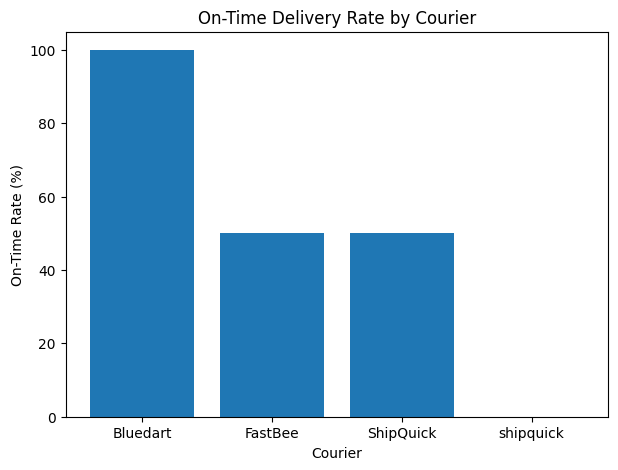

In [36]:
plt.figure(figsize=(7,5))

plt.bar(summary["courier"], summary["on_time_rate"] * 100)

plt.xlabel("Courier")
plt.ylabel("On-Time Rate (%)")
plt.title("On-Time Delivery Rate by Courier")

plt.show()

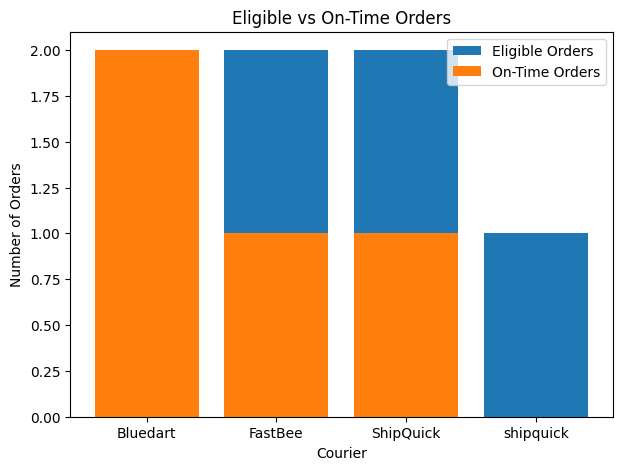

In [37]:
plt.figure(figsize=(7,5))

plt.bar(summary["courier"], summary["eligible_orders"], label="Eligible Orders")
plt.bar(summary["courier"], summary["on_time_orders"], label="On-Time Orders")

plt.xlabel("Courier")
plt.ylabel("Number of Orders")
plt.title("Eligible vs On-Time Orders")

plt.legend()
plt.show()

In [38]:
df.head(10)

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,29-04-26,2026-05-01,2026-05-03,03-05-26,Bengaluru,ShipQuick,Paid,Delivered,2,1200,No
1,O1002,C02,02-05-26,2026-05-03,2026-05-07,07-05-26,Mumbai,shipquick,pending,delivered,3,900,No
2,O1002,C02,02-05-26,2026-05-03,2026-05-07,08-05-26,Mumbai,ShipQuick,Paid,Delivered,3,900,No
3,O1003,C03,04-05-26,2026-05-05,2026-05-06,06-05-26,Delhi,FastBee,Pending,Delivered,2,650,No
4,O1004,C04,05-05-26,2026-05-06,2026-06-01,01-06-26,Pune,Blue Dart,Paid,Delivered,4,2000,No
5,O1005,C05,08-05-26,2026-05-09,NaT,10-05-26,Chennai,Fastbee,Paid,Cancelled,3,700,No
6,O1006,C06,10-05-26,2026-05-11,2026-05-14,14-05-26,Mumbai,Bluedart,Paid,Delivered,3,1500,No
7,O1006,C06,10-05-26,2026-05-11,2026-05-14,14-05-26,Mumbai,Bluedart,Paid,Delivered,3,1500,No
8,O1007,C07,12-05-26,2026-05-13,2026-05-15,15-05-26,Bangalore,ShipQuick,Paid,Delivered,2,1,Yes
9,O1008,C08,15-05-26,2026-05-16,2026-05-18,18-05-26,Pune,FastBee,Paid,Delivered,-2,500,No


In [39]:
may_order

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order,delivery_duration,effective_promised_days,is_on_time
0,O1001,C01,29-04-26,2026-05-01,2026-05-03,03-05-26,Bengaluru,ShipQuick,Paid,Delivered,2,1200,No,2,2,True
1,O1002,C02,02-05-26,2026-05-03,2026-05-07,07-05-26,Mumbai,shipquick,pending,delivered,3,900,No,4,3,False
2,O1002,C02,02-05-26,2026-05-03,2026-05-07,08-05-26,Mumbai,ShipQuick,Paid,Delivered,3,900,No,4,3,False
3,O1003,C03,04-05-26,2026-05-05,2026-05-06,06-05-26,Delhi,FastBee,Pending,Delivered,2,650,No,1,2,True
6,O1006,C06,10-05-26,2026-05-11,2026-05-14,14-05-26,Mumbai,Bluedart,Paid,Delivered,3,1500,No,3,3,True
7,O1006,C06,10-05-26,2026-05-11,2026-05-14,14-05-26,Mumbai,Bluedart,Paid,Delivered,3,1500,No,3,3,True
9,O1008,C08,15-05-26,2026-05-16,2026-05-18,18-05-26,Pune,FastBee,Paid,Delivered,-2,500,No,2,0,False


### #Ignore Below Code

In [46]:
!git clone https://github.com/RayRenaissance/marketplace-delivery2.git

Cloning into 'marketplace-delivery2'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [47]:
%cd marketplace-delivery2

/content/marketplace-delivery2/marketplace-delivery2


In [48]:
!cp /content/task1_marketplace_delivery_sla_raw.csv .

In [49]:
!cp /content/marketplace_delivery_sla.ipynb .

cp: cannot stat '/content/marketplace_delivery_sla.ipynb': No such file or directory


In [50]:
!ls


task1_marketplace_delivery_sla_raw.csv
